# Multi-class outcome prediction — favored-team perspective (Elo-relabeled)
## End-to-end pipeline: raw DB → features → model → SHAP

| Class | Label | Meaning |
|-------|-------|---------|
| 0 | `fav_loses` | Higher-Elo team loses (upset) |
| 1 | `draw` | Match ends in a draw |
| 2 | `fav_wins` | Higher-Elo team wins |

**Sections**

- **A — Feature engineering**
  - A1 Load raw tables
  - A2 Base match table
  - A3 Historical team strength (past WCs only)
  - A4 Confederation win rates
  - A5 Squad makeup & experience
  - A6 Coaches
  - A7 Schedule & venue
  - A8 Finalise feature matrix
- **B — Modelling**
  - B1 Men's editions, Elo join & three-class label
  - B2 Feature matrix (fav-*/und-* perspective)
  - B3 Phase 1 — LOTO cross-validation model comparison
  - B4 Phase 2 — Bayesian hyperparameter tuning (Optuna)
  - B5 Phase 3 — Final evaluation on 2018 + 2022 joint holdout
  - B6 Phase 4 — SHAP feature importance

**Data sources:** `worldcup/data-sqlite/worldcup.db`, `data/elo_ratings.csv`

**Requirements:** `shap`, `lightgbm`, `xgboost`, `optuna`


## A1 — Imports & setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import sqlite3, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

import lightgbm as lgb
import xgboost as xgb
import optuna

try:
    import shap
except ImportError:
    raise ImportError("Run: pip install shap")

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42

# Repo root (this notebook lives in notebooks/model/, two levels up)
BASE = Path("../../")
DB_PATH = BASE / "data/raw/worldcup/data-sqlite/worldcup.db"
assert DB_PATH.is_file(), f"SQLite DB not found: {DB_PATH}"

## A2 — Load raw tables from SQLite + Elo CSV

In [2]:
con = sqlite3.connect(DB_PATH)


def _sql(q):
    return pd.read_sql_query(q, con)


matches = _sql("SELECT * FROM matches")
tournaments = _sql("SELECT * FROM tournaments")
teams = _sql("SELECT * FROM teams")
stadiums = _sql("SELECT * FROM stadiums")
team_appearances = _sql("SELECT * FROM team_appearances")
squads = _sql("SELECT * FROM squads")
players = _sql("SELECT * FROM players")
manager_appointments = _sql("SELECT * FROM manager_appointments")
managers = _sql("SELECT * FROM managers")
manager_appearances = _sql("SELECT * FROM manager_appearances")
referee_appearances = _sql("SELECT * FROM referee_appearances")

# Outcome flags (used later for 3-class label)
mdb = _sql("SELECT match_id, home_team_win, away_team_win, draw FROM matches")
con.close()

# Parse dates
tournaments["start_dt"] = pd.to_datetime(
    tournaments["start_date"], unit="D", origin="unix", errors="coerce"
)
matches["match_dt"] = pd.to_datetime(
    matches["match_date"], unit="D", origin="unix", errors="coerce"
)
tourn_year = tournaments[["tournament_id", "year", "host_country", "start_dt"]].copy()
matches = matches.merge(tourn_year, on="tournament_id", how="left", suffixes=("", "_t"))

# Elo ratings
elo_raw = pd.read_csv(BASE / "data/raw/elo_ratings.csv")

print(f"matches          : {matches.shape}")
print(f"team_appearances : {team_appearances.shape}")
print(f"squads           : {squads.shape}")
print(f"players          : {players.shape}")
print(f"elo_raw          : {elo_raw.shape}")
print(
    f"Tournament years : {int(tournaments.year.min())} – {int(tournaments.year.max())}"
)

matches          : (1248, 32)
team_appearances : (2496, 17)
squads           : (13843, 6)
players          : (10401, 12)
elo_raw          : (17200, 17)
Tournament years : 1930 – 2022


## A3 — Base match table

One row per game (home-team perspective). Joins team metadata, stadium, and
two derived flags: `same_confederation` and `is_host_nation`.

In [3]:
base = matches[
    [
        "match_id",
        "tournament_id",
        "year",
        "host_country",
        "home_team_id",
        "away_team_id",
        "match_dt",
        "stage_name",
        "group_name",
        "group_stage",
        "knockout_stage",
        "replayed",
        "replay",
        "stadium_id",
        "home_team_win",
    ]
].copy()

base["y_win"] = base["home_team_win"].astype("Int64").fillna(0).astype(int)

th = teams.rename(columns={c: f"home_{c}" for c in teams.columns if c != "team_id"})
ta = teams.rename(columns={c: f"away_{c}" for c in teams.columns if c != "team_id"})
base = base.merge(th, left_on="home_team_id", right_on="team_id", how="left").drop(
    columns=["team_id"]
)
base = base.merge(ta, left_on="away_team_id", right_on="team_id", how="left").drop(
    columns=["team_id"]
)
base = base.merge(stadiums, on="stadium_id", how="left", suffixes=("", "_stadium"))

base["feat_same_confederation"] = (
    base["home_confederation_id"] == base["away_confederation_id"]
).astype(int)


def _norm(s):
    return s.astype(str).str.strip().str.lower().str.replace(" ", "", regex=False)


base["feat_home_is_host_nation"] = (
    _norm(base["home_team_name"]) == _norm(base["host_country"])
).astype(int)
base["feat_away_is_host_nation"] = (
    _norm(base["away_team_name"]) == _norm(base["host_country"])
).astype(int)

print(f"base shape: {base.shape}")

base shape: (1248, 45)


## A4 — Historical team strength (past WCs only)

For each team × tournament, we compute match counts, win/draw/loss, goal
difference, knockout rates etc. using **only** tournaments with `year <`
this tournament.  Win rates are Laplace-smoothed with a (2, 2) prior.

In [4]:
ta_hist = team_appearances.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id", how="left"
)
ta_hist = ta_hist.merge(
    matches[["match_id", "knockout_stage", "group_stage"]],
    on="match_id",
    how="left",
    suffixes=("", "_m"),
)

ALPHA, BETA = 2.0, 2.0


def shrink_win_rate(w, n, a=ALPHA, b=BETA):
    return (w + a) / (n + a + b) if n > 0 else a / (a + b)


def prior_team_stats(team_id, before_year):
    sub = ta_hist[(ta_hist["team_id"] == team_id) & (ta_hist["year"] < before_year)]
    if sub.empty:
        return dict(
            n_tournaments=0,
            n_matches=0,
            wins=0,
            draws=0,
            losses=0,
            goal_diff_sum=0,
            ko_matches=0,
            ko_wins=0,
            pso_matches=0,
            pso_wins=0,
            et_matches=0,
            tournaments_with_ko_game=0,
        )
    ko = sub[sub["knockout_stage"] == 1]
    pso = sub[sub["penalty_shootout"] == 1]
    return dict(
        n_tournaments=sub["tournament_id"].nunique(),
        n_matches=len(sub),
        wins=int(sub["win"].sum()),
        draws=int(sub["draw"].sum()),
        losses=int(sub["lose"].sum()),
        goal_diff_sum=float((sub["goals_for"] - sub["goals_against"]).sum()),
        ko_matches=len(ko),
        ko_wins=int(ko["win"].sum()),
        pso_matches=len(pso),
        pso_wins=int((pso["penalties_for"] > pso["penalties_against"]).sum()),
        et_matches=int(sub["extra_time"].sum()),
        tournaments_with_ko_game=len(set(ko["tournament_id"].unique())),
    )


# Build cache once for all team-year combos
years = sorted(base["year"].dropna().unique())
all_tids = pd.unique(
    np.concatenate([base["home_team_id"].values, base["away_team_id"].values])
)
cache = {
    (tid, int(y)): prior_team_stats(tid, int(y)) for tid in all_tids for y in years
}


def attach_hist(df, prefix, team_col):
    rows = [cache[(r[team_col], int(r["year"]))] for _, r in df.iterrows()]
    h = pd.DataFrame(rows).add_prefix(f"{prefix}hist_")
    pfx = f"{prefix}hist_"
    h[f"{pfx}win_rate_shrunk"] = [
        shrink_win_rate(int(w), int(n))
        for w, n in zip(h[f"{pfx}wins"], h[f"{pfx}n_matches"])
    ]
    h[f"{pfx}goal_diff_per_match"] = np.where(
        h[f"{pfx}n_matches"] > 0,
        h[f"{pfx}goal_diff_sum"] / h[f"{pfx}n_matches"],
        np.nan,
    )
    h[f"{pfx}ko_win_rate_shrunk"] = [
        shrink_win_rate(int(kw), int(km))
        for kw, km in zip(h[f"{pfx}ko_wins"], h[f"{pfx}ko_matches"])
    ]
    h[f"{pfx}pso_win_rate_shrunk"] = [
        shrink_win_rate(int(pw), int(pm)) if pm > 0 else np.nan
        for pw, pm in zip(h[f"{pfx}pso_wins"], h[f"{pfx}pso_matches"])
    ]
    h[f"{pfx}et_rate"] = np.where(
        h[f"{pfx}n_matches"] > 0, h[f"{pfx}et_matches"] / h[f"{pfx}n_matches"], np.nan
    )
    h[f"{pfx}frac_tournaments_reached_ko"] = np.where(
        h[f"{pfx}n_tournaments"] > 0,
        h[f"{pfx}tournaments_with_ko_game"] / h[f"{pfx}n_tournaments"],
        np.nan,
    )
    return pd.concat([df.reset_index(drop=True), h], axis=1)


base = attach_hist(base, "home_", "home_team_id")
base = attach_hist(base, "away_", "away_team_id")

base["feat_hist_win_rate_diff"] = (
    base["home_hist_win_rate_shrunk"] - base["away_hist_win_rate_shrunk"]
)
base["feat_hist_goal_diff_per_match_diff"] = (
    base["home_hist_goal_diff_per_match"] - base["away_hist_goal_diff_per_match"]
)
print(f"base after hist stats: {base.shape}")

base after hist stats: (1248, 83)


## A5 — Win rate vs. opponent's confederation (past WCs only)

In [5]:
opp_conf = teams[["team_id", "confederation_id"]].rename(
    columns={"team_id": "opponent_id", "confederation_id": "opponent_confederation_id"}
)
ta_oc = ta_hist.merge(opp_conf, on="opponent_id", how="left")


def rate_vs_conf(team_id, before_year, opp_conf_id):
    if pd.isna(opp_conf_id):
        return np.nan
    sub = ta_oc[
        (ta_oc["team_id"] == team_id)
        & (ta_oc["year"] < before_year)
        & (ta_oc["opponent_confederation_id"] == opp_conf_id)
    ]
    return shrink_win_rate(int(sub["win"].sum()), len(sub)) if not sub.empty else np.nan


base["feat_home_hist_win_rate_vs_away_conf"] = [
    rate_vs_conf(h, int(y), c)
    for h, y, c in zip(
        base["home_team_id"], base["year"], base["away_confederation_id"]
    )
]
base["feat_away_hist_win_rate_vs_home_conf"] = [
    rate_vs_conf(a, int(y), c)
    for a, y, c in zip(
        base["away_team_id"], base["year"], base["home_confederation_id"]
    )
]
print("Confederation features attached.")

Confederation features attached.


## A6 — Squad makeup & experience

Ages at tournament start, position counts, share of players with prior WC
experience, and Jaccard overlap with the previous WC squad.

In [6]:
sq = squads.merge(tourn_year[["tournament_id", "year", "start_dt"]], on="tournament_id")
sq = sq.merge(players, on="player_id", how="left")
sq["birth_dt"] = pd.to_datetime(sq["birth_date"], errors="coerce")

# Count prior WC appearances per player (only years < current)
pyt = sq[["player_id", "tournament_id", "year"]].drop_duplicates()
prior_rows = []
for (pid, y), g in pyt.groupby(["player_id", "year"]):
    n_prior = pyt[(pyt["player_id"] == pid) & (pyt["year"] < y)][
        "tournament_id"
    ].nunique()
    prior_rows.append({"player_id": pid, "year": y, "prior_wc_played": n_prior})
prior_wc = pd.DataFrame(prior_rows)
sq = sq.merge(prior_wc, on=["player_id", "year"], how="left")
sq["age_at_tournament"] = (sq["start_dt"] - sq["birth_dt"]).dt.days / 365.25
for col in ["goal_keeper", "defender", "midfielder", "forward"]:
    sq[col] = sq[col].fillna(0).astype(int)


def squad_row(g):
    return dict(
        n_players=len(g),
        age_mean=g["age_at_tournament"].mean(),
        age_median=g["age_at_tournament"].median(),
        age_std=g["age_at_tournament"].std(),
        age_min=g["age_at_tournament"].min(),
        age_max=g["age_at_tournament"].max(),
        n_gk=int(g["goal_keeper"].sum()),
        n_df=int(g["defender"].sum()),
        n_mf=int(g["midfielder"].sum()),
        n_fw=int(g["forward"].sum()),
        prior_wc_mean=g["prior_wc_played"].mean(),
        prior_wc_median=g["prior_wc_played"].median(),
        share_any_prior_wc=(g["prior_wc_played"] > 0).mean(),
        share_ge2_prior_wc=(g["prior_wc_played"] >= 2).mean(),
    )


squad_records = [
    {"tournament_id": tid, "team_id": tmid, **squad_row(g)}
    for (tid, tmid), g in sq.groupby(["tournament_id", "team_id"])
]
squad_feats = pd.DataFrame(squad_records)

# Squad overlap vs previous WC
overlap_records = []
for (team_id,), g in sq.groupby(["team_id"]):
    g = g.sort_values("year")
    years_order = g["year"].unique()
    prev_players, prev_year = None, None
    for y in years_order:
        cur = set(g.loc[g["year"] == y, "player_id"].unique())
        if prev_players is not None:
            inter = len(cur & prev_players)
            uni = len(cur | prev_players)
            overlap_records.append(
                dict(
                    team_id=team_id,
                    year=y,
                    squad_jaccard_vs_prev_wc=inter / uni if uni else np.nan,
                    squad_overlap_count_vs_prev_wc=inter,
                )
            )
        prev_players, prev_year = cur, int(y)
overlap_df = pd.DataFrame(overlap_records)

squad_feats = squad_feats.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id", how="left"
)
squad_feats = squad_feats.merge(overlap_df, on=["team_id", "year"], how="left")


def _squad_side(sf, prefix, team_col):
    sf2 = sf.rename(
        columns={
            c: f"{prefix}squad_{c}"
            for c in sf.columns
            if c not in ("tournament_id", "team_id", "year")
        }
    )
    sf2 = sf2.rename(columns={"team_id": team_col})
    sf2 = sf2.drop(columns=["year"], errors="ignore")
    return sf2


base = base.merge(
    _squad_side(squad_feats, "home_", "home_team_id"),
    on=["tournament_id", "home_team_id"],
    how="left",
)
base = base.merge(
    _squad_side(squad_feats, "away_", "away_team_id"),
    on=["tournament_id", "away_team_id"],
    how="left",
)

base["feat_squad_age_mean_diff"] = (
    base["home_squad_age_mean"] - base["away_squad_age_mean"]
)
base["feat_squad_prior_wc_mean_diff"] = (
    base["home_squad_prior_wc_mean"] - base["away_squad_prior_wc_mean"]
)
print(f"base after squad features: {base.shape}")

base after squad features: (1248, 119)


## A7 — Coaches

Whether the coach is a local (same nationality as team), number of prior WCs
managed, historical win rate in past WC matches, and consecutive tournaments
with the same team.

In [7]:
ma = manager_appointments.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id"
)
ma = ma.merge(managers, on="manager_id", how="left")
ma_pick = ma.sort_values("manager_id").drop_duplicates(
    subset=["tournament_id", "team_id"], keep="first"
)


def _mgr_side(prefix, side_col):
    cols = {
        "manager_id": f"{prefix}manager_id",
        "country_name": f"{prefix}manager_country_name",
        "female": f"{prefix}manager_female",
    }
    df = ma_pick.rename(columns=cols)
    df = df.rename(columns={"team_id": side_col})
    return df[
        [
            "tournament_id",
            side_col,
            f"{prefix}manager_id",
            f"{prefix}manager_country_name",
            f"{prefix}manager_female",
        ]
    ]


base = base.merge(
    _mgr_side("home_", "home_team_id"), on=["tournament_id", "home_team_id"], how="left"
)
base = base.merge(
    _mgr_side("away_", "away_team_id"), on=["tournament_id", "away_team_id"], how="left"
)

base["feat_home_manager_local"] = (
    _norm(base["home_manager_country_name"]) == _norm(base["home_team_name"])
).astype(int)
base["feat_away_manager_local"] = (
    _norm(base["away_manager_country_name"]) == _norm(base["away_team_name"])
).astype(int)

# Prior WC count per manager
mgr_tourneys = (
    ma_pick[["manager_id", "tournament_id", "year"]]
    .drop_duplicates()
    .sort_values(["manager_id", "year"])
)
mgr_prior_rows = []
for mid, g in mgr_tourneys.groupby("manager_id"):
    for i, (_, r) in enumerate(g.iterrows()):
        mgr_prior_rows.append(
            {
                "manager_id": mid,
                "tournament_id": r["tournament_id"],
                "mgr_n_prior_wc": i,
            }
        )
mgr_prior_df = pd.DataFrame(mgr_prior_rows)

for side in ["home", "away"]:
    tmp = mgr_prior_df.rename(
        columns={
            "manager_id": f"{side}_manager_id",
            "mgr_n_prior_wc": f"{side}_mgr_n_prior_wc",
        }
    )
    base = base.merge(
        tmp[[f"{side}_manager_id", "tournament_id", f"{side}_mgr_n_prior_wc"]],
        on=[f"{side}_manager_id", "tournament_id"],
        how="left",
    )

# Historical win rate per manager in past WC matches
mapp = manager_appearances.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id"
).merge(
    team_appearances[["tournament_id", "match_id", "team_id", "win"]],
    on=["tournament_id", "match_id", "team_id"],
    how="left",
)


def mgr_hist_win_rate(manager_id, before_year):
    sub = mapp[(mapp["manager_id"] == manager_id) & (mapp["year"] < before_year)]
    sub = sub.dropna(subset=["win"])
    return shrink_win_rate(int(sub["win"].sum()), len(sub)) if not sub.empty else np.nan


base["feat_home_mgr_hist_win_rate_shrunk"] = [
    mgr_hist_win_rate(m, int(y)) if pd.notna(m) else np.nan
    for m, y in zip(base["home_manager_id"], base["year"])
]
base["feat_away_mgr_hist_win_rate_shrunk"] = [
    mgr_hist_win_rate(m, int(y)) if pd.notna(m) else np.nan
    for m, y in zip(base["away_manager_id"], base["year"])
]

# Consecutive tournaments with same team
streak_rows = []
for (mid, tid), g in ma_pick.sort_values("year").groupby(["manager_id", "team_id"]):
    g = g.drop_duplicates(subset=["tournament_id", "year"]).sort_values("year")
    yrs = g["year"].astype(int).tolist()
    tids = g["tournament_id"].tolist()
    run = 0
    for i, y in enumerate(yrs):
        run = (run + 1) if (i == 0 or y - yrs[i - 1] in (1, 4)) else 1
        streak_rows.append(
            {
                "manager_id": mid,
                "team_id": tid,
                "tournament_id": tids[i],
                "mgr_consecutive_wc_with_team": run,
            }
        )
streak_df = pd.DataFrame(streak_rows)

for side in ["home", "away"]:
    tmp = streak_df.rename(
        columns={
            "manager_id": f"{side}_manager_id",
            "team_id": f"{side}_team_id",
            "mgr_consecutive_wc_with_team": f"{side}_mgr_consecutive_wc_with_team",
        }
    )
    base = base.merge(
        tmp[
            [
                f"{side}_manager_id",
                f"{side}_team_id",
                "tournament_id",
                f"{side}_mgr_consecutive_wc_with_team",
            ]
        ],
        on=[f"{side}_manager_id", f"{side}_team_id", "tournament_id"],
        how="left",
    )
print(f"base after coach features: {base.shape}")

base after coach features: (1248, 133)


## A8 — Schedule & venue

Rest days since previous game within the tournament (calendar only, no
result data) and number of referees assigned to the match.

In [8]:
sched = matches[
    ["match_id", "tournament_id", "home_team_id", "away_team_id", "match_dt", "year"]
].copy()
long_sched = pd.concat(
    [
        sched.rename(
            columns={"home_team_id": "team_id", "away_team_id": "opponent_id"}
        ),
        sched.rename(
            columns={"away_team_id": "team_id", "home_team_id": "opponent_id"}
        ),
    ],
    ignore_index=True,
).sort_values(["tournament_id", "team_id", "match_dt", "match_id"])
long_sched["prev_match_dt"] = long_sched.groupby(["tournament_id", "team_id"])[
    "match_dt"
].shift(1)
long_sched["rest_days"] = (long_sched["match_dt"] - long_sched["prev_match_dt"]).dt.days

for side in ["home", "away"]:
    rest = long_sched.rename(
        columns={
            "rest_days": f"{side}_rest_days_since_prev_match",
            "team_id": f"{side}_team_id",
        }
    )[[f"match_id", f"{side}_team_id", f"{side}_rest_days_since_prev_match"]]
    base = base.merge(rest, on=["match_id", f"{side}_team_id"], how="left")

base["feat_rest_days_diff"] = (
    base["home_rest_days_since_prev_match"] - base["away_rest_days_since_prev_match"]
)

nref = referee_appearances.groupby("match_id").size().reset_index(name="n_referees")
base = base.merge(nref, on="match_id", how="left")
base["n_referees"] = base["n_referees"].fillna(0).astype(int)
print(f"base after schedule features: {base.shape}")

base after schedule features: (1248, 137)


## A9 — Finalise feature matrix (`df_all`)

Selects the same column set that notebook 01 exports to `class_a_match_level.parquet`,
giving identical inputs to the modelling section.

In [9]:
ID_COLS = ["match_id", "tournament_id", "year", "home_team_id", "away_team_id"]
LABEL = "y_win"

numeric_hist = [
    c for c in base.columns if c.startswith("home_hist_") or c.startswith("away_hist_")
]
numeric_squad = [
    c
    for c in base.columns
    if c.startswith("home_squad_") or c.startswith("away_squad_")
]
feat_prefixed = [c for c in base.columns if c.startswith("feat_")]
mgr_numeric = [
    "home_mgr_n_prior_wc",
    "away_mgr_n_prior_wc",
    "feat_home_mgr_hist_win_rate_shrunk",
    "feat_away_mgr_hist_win_rate_shrunk",
    "home_mgr_consecutive_wc_with_team",
    "away_mgr_consecutive_wc_with_team",
    "feat_home_manager_local",
    "feat_away_manager_local",
]
schedule_ctx = [
    "group_stage",
    "knockout_stage",
    "replayed",
    "replay",
    "stadium_capacity",
    "home_rest_days_since_prev_match",
    "away_rest_days_since_prev_match",
    "n_referees",
]
FEATURE_COLS = sorted(
    set(numeric_hist + numeric_squad + feat_prefixed + mgr_numeric + schedule_ctx)
)
EXPORT_COLS = ID_COLS + [LABEL] + FEATURE_COLS + ["stage_name", "group_name"]

# also keep team name columns needed for Elo lookup
EXTRA = ["home_team_name", "away_team_name"]

df_all = base[[c for c in EXPORT_COLS + EXTRA if c in base.columns]].copy()
print(f"df_all shape : {df_all.shape}  (matches notebook-01 output of 1248 x ~104)")

df_all shape : (1248, 104)  (matches notebook-01 output of 1248 x ~104)


---
## B1 — Men's editions, Elo join & three-class label

In [10]:
MENS_WC_YEARS = [2002, 2006, 2010, 2014, 2018, 2022]

men = df_all[df_all["year"].isin(MENS_WC_YEARS)].copy()

# Name aliases: DB names → Elo dataset names
NAME_MAP = {
    "Czech Republic": "Czechia",
    "Republic of Ireland": "Ireland",
    "West Germany": "Germany",
    "Serbia and Montenegro": "Serbia",
}
team_lookup = teams[["team_id", "team_name"]].copy()
team_lookup["elo_name"] = team_lookup["team_name"].map(lambda x: NAME_MAP.get(x, x))
elo_yr = elo_raw[["year", "team", "rating"]].rename(columns={"team": "elo_name"})

for side in ["home", "away"]:
    tmp = (
        men[[f"{side}_team_id", "year"]]
        .merge(
            team_lookup[["team_id", "elo_name"]],
            left_on=f"{side}_team_id",
            right_on="team_id",
            how="left",
        )
        .merge(elo_yr, on=["elo_name", "year"], how="left")
    )
    men[f"{side}_elo"] = tmp["rating"].values

men = men.dropna(subset=["home_elo", "away_elo"]).copy()
men["fav_side"] = np.where(men["home_elo"] >= men["away_elo"], "home", "away")

# 3-way outcome from DB flags
mdb["home_result"] = np.select(
    [mdb["home_team_win"] == 1, mdb["draw"] == 1], ["W", "D"], default="L"
)
mdb["home_result"] = mdb["home_result"].where(
    mdb[["home_team_win", "draw"]].notna().all(axis=1), other=None
)
men = men.merge(mdb[["match_id", "home_result"]], on="match_id", how="left")
men = men.dropna(subset=["home_result"]).copy()

# 3-class label: 2=fav wins, 1=draw, 0=fav loses
men["y3"] = np.select(
    [
        (men["fav_side"] == "home") & (men["home_result"] == "W"),
        (men["fav_side"] == "away") & (men["home_result"] == "L"),
        men["home_result"] == "D",
    ],
    [2, 2, 1],
    default=0,
)

print(f"Rows: {len(men)}")
print("Label distribution (0=fav_loses, 1=draw, 2=fav_wins):")
print(men["y3"].value_counts().sort_index())
print(
    f"Class rates: {men['y3'].value_counts(normalize=True).sort_index().round(3).to_dict()}"
)

Rows: 384
Label distribution (0=fav_loses, 1=draw, 2=fav_wins):
y3
0     63
1     67
2    254
Name: count, dtype: int64
Class rates: {0: 0.164, 1: 0.174, 2: 0.661}


## B2 — Feature matrix (fav-* / und-* perspective)

`home_*` / `away_*` columns are swapped based on which team is Elo-favored,
giving a consistent "stronger team" vs "weaker team" view.
We add `elo_gap`, `fav_elo`, `und_elo` as explicit numeric features.

In [11]:
id_cols = {
    "match_id",
    "year",
    "home_team_id",
    "away_team_id",
    "home_team_name",
    "away_team_name",
    "match_dt",
    "tournament_id",
    "stage_name",
    "group_name",
    "group",
    "round",
    "home_elo",
    "away_elo",
    "fav_side",
    "home_result",
}
non_feature = {"y_win", "y3", "home_squad_year", "away_squad_year"}
skip = id_cols | non_feature

orig_num = [
    c for c in men.columns if c not in skip and pd.api.types.is_numeric_dtype(men[c])
]
home_cols = [c for c in orig_num if c.startswith("home_")]
other_num = [c for c in orig_num if not c.startswith(("home_", "away_"))]

fav_df = men.copy()
away_fav_mask = men["fav_side"] == "away"

for hcol in home_cols:
    acol = "away_" + hcol[5:]
    if acol not in men.columns:
        continue
    fav_df["fav_" + hcol[5:]] = np.where(away_fav_mask, men[acol], men[hcol])
    fav_df["und_" + hcol[5:]] = np.where(away_fav_mask, men[hcol], men[acol])

fav_df["elo_gap"] = np.where(
    men["fav_side"] == "home",
    men["home_elo"] - men["away_elo"],
    men["away_elo"] - men["home_elo"],
)
fav_df["fav_elo"] = np.where(
    men["fav_side"] == "home", men["home_elo"], men["away_elo"]
)
fav_df["und_elo"] = np.where(
    men["fav_side"] == "home", men["away_elo"], men["home_elo"]
)

feat_other = [c for c in other_num if c in fav_df.columns]
fav_num_cols = (
    [
        c
        for c in fav_df.columns
        if c.startswith(("fav_", "und_")) and pd.api.types.is_numeric_dtype(fav_df[c])
    ]
    + ["elo_gap"]
    + feat_other
)

X_all = fav_df[fav_num_cols].copy()
y_all = fav_df["y3"].values

print(f"Feature matrix: {X_all.shape}  |  classes: {np.unique(y_all)}")

Feature matrix: (384, 97)  |  classes: [0 1 2]


## B3 — Phase 1: LOTO cross-validation model comparison

Leave-One-Tournament-Out CV: hold out each men's World Cup in turn and
measure **macro-averaged F1**, **accuracy**, and **macro-ROC-AUC** (OvR).

Models compared: Logistic Regression, Random Forest, LightGBM, XGBoost.
All use `class_weight="balanced"` (or equivalent) for class imbalance.

LOTO mean metrics (2002–2014 training tournaments):
              accuracy  macro_f1  macro_auc
model                                      
XGBoost          0.664     0.472      0.671
LightGBM         0.656     0.458      0.682
LogReg           0.516     0.425      0.648
RandomForest     0.664     0.277      0.686

→ Best model by macro-F1: XGBoost


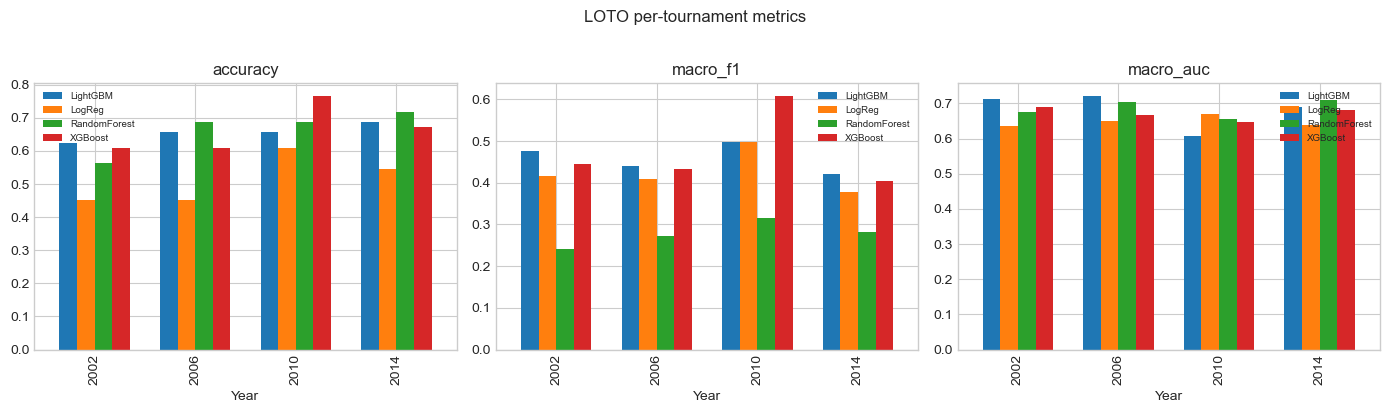

In [12]:
IMP = SimpleImputer(strategy="median")
SCL = StandardScaler()


def preprocess(X_tr, X_te):
    imp = SimpleImputer(strategy="median").fit(X_tr)
    scl = StandardScaler().fit(imp.transform(X_tr))
    return scl.transform(imp.transform(X_tr)), scl.transform(imp.transform(X_te))


def make_candidates():
    return {
        "LogReg": LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            C=1.0,
            class_weight="balanced",
            random_state=SEED,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
            verbose=-1,
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=400,
            num_class=3,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=1,
            verbosity=0,
        ),
    }


# LOTO is run only on the training window (2002-2014); 2018+2022 are held out.
loto_years = sorted(y for y in fav_df["year"].unique() if y < 2018)
loto_records = []

for test_year in loto_years:
    mask_te = fav_df["year"] == test_year
    X_tr_raw = X_all[~mask_te].values
    y_tr = y_all[~mask_te]
    X_te_raw = X_all[mask_te].values
    y_te = y_all[mask_te]
    if len(np.unique(y_tr)) < 3 or len(y_te) == 0:
        continue
    X_tr, X_te = preprocess(X_tr_raw, X_te_raw)

    for name, mdl in make_candidates().items():
        m = clone(mdl)
        if name == "XGBoost":
            sw = compute_sample_weight("balanced", y_tr)
            m.fit(X_tr, y_tr, sample_weight=sw)
        else:
            m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        proba = m.predict_proba(X_te)
        try:
            auc = roc_auc_score(
                label_binarize(y_te, classes=[0, 1, 2]),
                proba,
                multi_class="ovr",
                average="macro",
            )
        except Exception:
            auc = np.nan
        loto_records.append(
            dict(
                model=name,
                year=test_year,
                accuracy=accuracy_score(y_te, y_pred),
                macro_f1=f1_score(y_te, y_pred, average="macro", zero_division=0),
                macro_auc=auc,
            )
        )

loto_df = pd.DataFrame(loto_records)
summary = (
    loto_df.groupby("model")[["accuracy", "macro_f1", "macro_auc"]]
    .mean()
    .sort_values("macro_f1", ascending=False)
)
print("LOTO mean metrics (2002–2014 training tournaments):")
print(summary.round(3))

best_model_name = summary["macro_f1"].idxmax()
print(f"\n→ Best model by macro-F1: {best_model_name}")

# Bar-chart of per-tournament macro-F1
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["accuracy", "macro_f1", "macro_auc"]):
    pivot = loto_df.pivot(index="year", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, width=0.7)
    ax.set_title(metric)
    ax.set_xlabel("Year")
    ax.legend(fontsize=7)
plt.suptitle("LOTO per-tournament metrics", y=1.02)
plt.tight_layout()
plt.show()

## B4 — Phase 2: Bayesian hyperparameter tuning (Optuna)

We tune **only the best model** from Phase 1 (by macro-F1) using Optuna
with the TPE sampler and 40 trials of 3-fold stratified CV on all data
except 2018 + 2022.

In [13]:
mask_tune = fav_df["year"] < 2018  # tune on 2002-2014 only
X_tune_raw = X_all[mask_tune].values
y_tune = y_all[mask_tune]

_imp = SimpleImputer(strategy="median").fit(X_tune_raw)
_scl = StandardScaler().fit(_imp.transform(X_tune_raw))
X_tune = _scl.transform(_imp.transform(X_tune_raw))

CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)


def make_objective(model_name):
    def objective(trial):
        if model_name == "LightGBM":
            params = dict(
                n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                num_leaves=trial.suggest_int("num_leaves", 15, 127),
                min_child_samples=trial.suggest_int("min_child_samples", 5, 50),
                subsample=trial.suggest_float("subsample", 0.5, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
                reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
                class_weight="balanced",
                random_state=SEED,
                n_jobs=1,
                verbose=-1,
            )
            mdl = lgb.LGBMClassifier(**params)
        elif model_name == "XGBoost":
            params = dict(
                n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                max_depth=trial.suggest_int("max_depth", 3, 8),
                subsample=trial.suggest_float("subsample", 0.5, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
                reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
                num_class=3,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=SEED,
                n_jobs=1,
                verbosity=0,
            )
            mdl = xgb.XGBClassifier(**params)
        elif model_name == "RandomForest":
            params = dict(
                n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
                max_depth=trial.suggest_int("max_depth", 3, 20),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
                max_features=trial.suggest_float("max_features", 0.3, 1.0),
                class_weight="balanced",
                random_state=SEED,
                n_jobs=1,
            )
            mdl = RandomForestClassifier(**params)
        else:  # LogReg
            C = trial.suggest_float("C", 1e-2, 10.0, log=True)
            mdl = LogisticRegression(
                C=C,
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=SEED,
            )
        scores = []
        for tr_idx, va_idx in CV3.split(X_tune, y_tune):
            m = clone(mdl)
            if model_name == "XGBoost":
                sw = compute_sample_weight("balanced", y_tune[tr_idx])
                m.fit(X_tune[tr_idx], y_tune[tr_idx], sample_weight=sw)
            else:
                m.fit(X_tune[tr_idx], y_tune[tr_idx])
            proba = m.predict_proba(X_tune[va_idx])
            try:
                auc = roc_auc_score(
                    label_binarize(y_tune[va_idx], classes=[0, 1, 2]),
                    proba,
                    multi_class="ovr",
                    average="macro",
                )
            except Exception:
                auc = 0.0
            scores.append(auc)
        return np.mean(scores)

    return objective


N_TRIALS = 40
study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(
    make_objective(best_model_name), n_trials=N_TRIALS, show_progress_bar=True
)

print(f"Best 3-fold macro-AUC: {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:<22}: {v}")

  0%|          | 0/40 [00:00<?, ?it/s]

Best 3-fold macro-AUC: 0.7113
Best hyperparameters:
  n_estimators          : 300
  learning_rate         : 0.017001142745178135
  max_depth             : 7
  subsample             : 0.5951152389756781
  colsample_bytree      : 0.9102483600702537
  reg_alpha             : 0.01620749791765232
  reg_lambda            : 0.29502034781204733


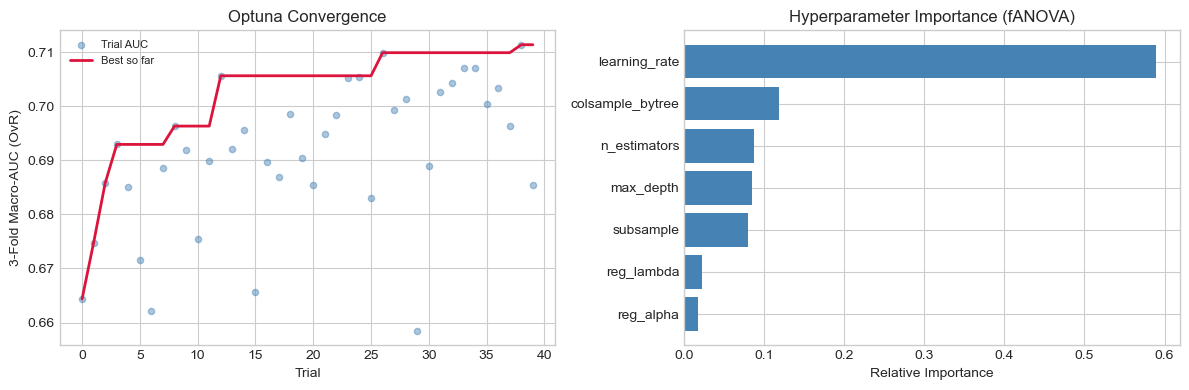

In [14]:
trials_df = study.trials_dataframe()
running_max = trials_df["value"].cummax()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.scatter(
    trials_df["number"],
    trials_df["value"],
    alpha=0.45,
    s=20,
    color="steelblue",
    label="Trial AUC",
)
ax.plot(
    trials_df["number"], running_max, color="crimson", linewidth=2, label="Best so far"
)
ax.set_xlabel("Trial")
ax.set_ylabel("3-Fold Macro-AUC (OvR)")
ax.set_title("Optuna Convergence")
ax.legend(fontsize=8)

try:
    importance = optuna.importance.get_param_importances(study)
    ax2 = axes[1]
    keys = list(importance.keys())[::-1]
    vals = list(importance.values())[::-1]
    ax2.barh(keys, vals, color="steelblue")
    ax2.set_xlabel("Relative Importance")
    ax2.set_title("Hyperparameter Importance (fANOVA)")
except Exception:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

## B5 — Phase 3: Final evaluation on 2018 + 2022 joint holdout

Train the tuned best model on 2002-2014, evaluate on 2018 + 2022. Also compare
against default versions of all four models for context.

2018+2022 joint holdout evaluation:
                 accuracy  macro_f1  macro_auc
model                                         
LightGBM            0.602     0.383      0.612
XGBoost (tuned)     0.609     0.373      0.627
XGBoost             0.586     0.361      0.593
LogReg              0.414     0.333      0.565
RandomForest        0.664     0.266      0.614


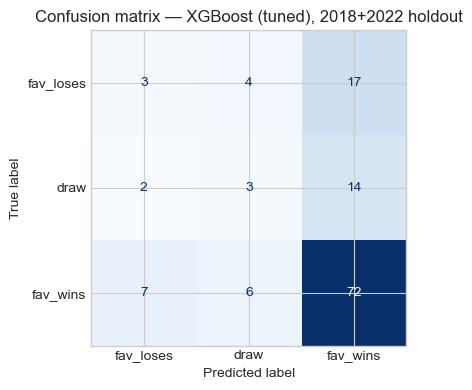

Classification report:
              precision    recall  f1-score   support

   fav_loses       0.25      0.12      0.17        24
        draw       0.23      0.16      0.19        19
    fav_wins       0.70      0.85      0.77        85

    accuracy                           0.61       128
   macro avg       0.39      0.38      0.37       128
weighted avg       0.55      0.61      0.57       128



In [15]:
bp = study.best_params
if best_model_name == "LightGBM":
    best_tuned = lgb.LGBMClassifier(
        **bp, class_weight="balanced", random_state=SEED, n_jobs=1, verbose=-1
    )
elif best_model_name == "XGBoost":
    best_tuned = xgb.XGBClassifier(
        **bp,
        num_class=3,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=1,
        verbosity=0,
    )
elif best_model_name == "RandomForest":
    best_tuned = RandomForestClassifier(
        **bp, class_weight="balanced", random_state=SEED, n_jobs=-1
    )
else:
    best_tuned = LogisticRegression(
        **bp, solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=SEED
    )

# Train on 2002-2014; hold out 2018+2022 together (~128 matches).
mask_tr22 = fav_df["year"] < 2018
mask_te22 = fav_df["year"] >= 2018
X_tr22_raw = X_all[mask_tr22].values
y_tr22 = y_all[mask_tr22]
X_te22_raw = X_all[mask_te22].values
y_te22 = y_all[mask_te22]
X_tr22, X_te22 = preprocess(X_tr22_raw, X_te22_raw)

if best_model_name == "XGBoost":
    sw22 = compute_sample_weight("balanced", y_tr22)
    best_tuned.fit(X_tr22, y_tr22, sample_weight=sw22)
else:
    best_tuned.fit(X_tr22, y_tr22)

CLASS_NAMES = ["fav_loses", "draw", "fav_wins"]
holdout_records = []
all_models = {**make_candidates(), f"{best_model_name} (tuned)": best_tuned}
for name, mdl in all_models.items():
    m = clone(mdl) if name != f"{best_model_name} (tuned)" else mdl
    if name != f"{best_model_name} (tuned)":
        if "XGBoost" in name:
            sw22 = compute_sample_weight("balanced", y_tr22)
            m.fit(X_tr22, y_tr22, sample_weight=sw22)
        else:
            m.fit(X_tr22, y_tr22)
    y_pred = m.predict(X_te22)
    proba = m.predict_proba(X_te22)
    try:
        auc = roc_auc_score(
            label_binarize(y_te22, classes=[0, 1, 2]),
            proba,
            multi_class="ovr",
            average="macro",
        )
    except Exception:
        auc = np.nan
    holdout_records.append(
        dict(
            model=name,
            accuracy=accuracy_score(y_te22, y_pred),
            macro_f1=f1_score(y_te22, y_pred, average="macro", zero_division=0),
            macro_auc=auc,
        )
    )

holdout_df = (
    pd.DataFrame(holdout_records)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)
print("2018+2022 joint holdout evaluation:")
print(holdout_df.round(3))

# Confusion matrix + report for best tuned model
y_pred_best = best_tuned.predict(X_te22)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te22, y_pred_best, display_labels=CLASS_NAMES, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confusion matrix — {best_model_name} (tuned), 2018+2022 holdout")
plt.tight_layout()
plt.show()

print("Classification report:")
print(
    classification_report(
        y_te22, y_pred_best, target_names=CLASS_NAMES, zero_division=0
    )
)

## B6 — Phase 4: SHAP feature importance

- For tree models (LightGBM / XGBoost / RandomForest): `shap.TreeExplainer`.
- For Logistic Regression: `shap.LinearExplainer`.

The **global mean |SHAP|** bar chart shows overall feature importance.
The **beeswarm per class** shows direction for each of the three outcome classes.

`check_additivity=False` suppresses a floating-point rounding artefact that
can appear when a background dataset is passed to TreeExplainer; it does not
affect the SHAP values themselves.

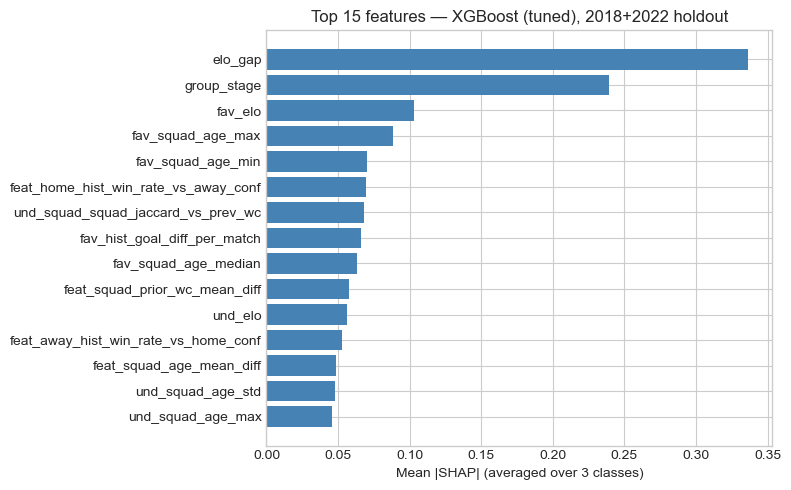

Top 15 features by mean |SHAP|:
elo_gap                                 0.3366
group_stage                             0.2394
fav_elo                                 0.1028
fav_squad_age_max                       0.0884
fav_squad_age_min                       0.0702
feat_home_hist_win_rate_vs_away_conf    0.0694
und_squad_squad_jaccard_vs_prev_wc      0.0683
fav_hist_goal_diff_per_match            0.0661
fav_squad_age_median                    0.0629
feat_squad_prior_wc_mean_diff           0.0577
und_elo                                 0.0564
feat_away_hist_win_rate_vs_home_conf    0.0526
feat_squad_age_mean_diff                0.0488
und_squad_age_std                       0.0476
und_squad_age_max                       0.0459


In [16]:
SHAP_SAMPLE = min(300, len(X_tr22))
tree_models = {"LightGBM", "XGBoost", "RandomForest"}
is_tree = best_model_name in tree_models

if is_tree:
    explainer = shap.TreeExplainer(best_tuned, data=X_tr22[:SHAP_SAMPLE])
    raw = explainer.shap_values(X_te22, check_additivity=False)
    # Handle both list-of-2D and 3D array returns across shap versions
    if isinstance(raw, np.ndarray) and raw.ndim == 3:
        shap_vals = [raw[:, :, c] for c in range(raw.shape[2])]
    else:
        shap_vals = raw
else:
    explainer = shap.LinearExplainer(best_tuned, X_tr22, feature_names=fav_num_cols)
    sv_obj = explainer(X_te22)
    shap_vals = [sv_obj.values[:, :, c] for c in range(3)]

# Global mean |SHAP| (averaged over all classes and samples)
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
feat_imp = pd.Series(mean_abs_shap, index=fav_num_cols).sort_values(ascending=False)

TOP_N = 15
top_feats = feat_imp.head(TOP_N)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_feats.index[::-1], top_feats.values[::-1], color="steelblue")
ax.set_xlabel("Mean |SHAP| (averaged over 3 classes)")
ax.set_title(f"Top {TOP_N} features — {best_model_name} (tuned), 2018+2022 holdout")
plt.tight_layout()
plt.show()

print(f"Top {TOP_N} features by mean |SHAP|:")
print(feat_imp.head(TOP_N).round(4).to_string())

Beeswarm — class 0: fav_loses


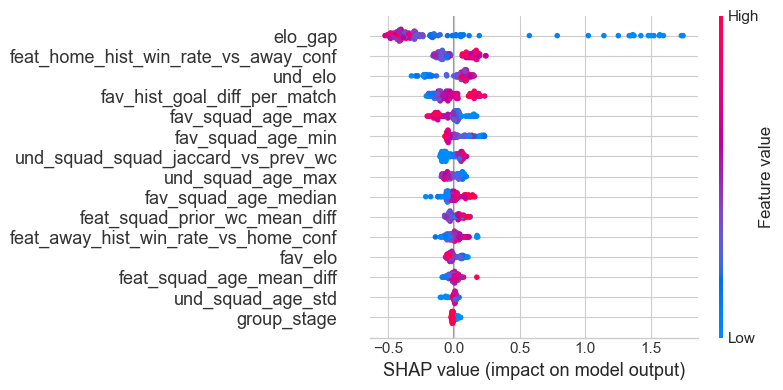

Beeswarm — class 1: draw


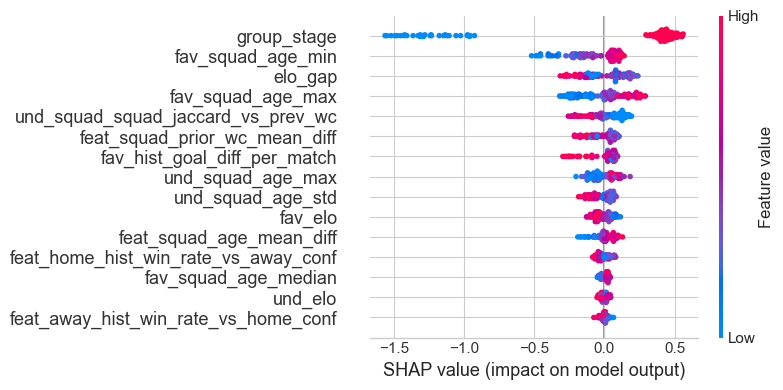

Beeswarm — class 2: fav_wins


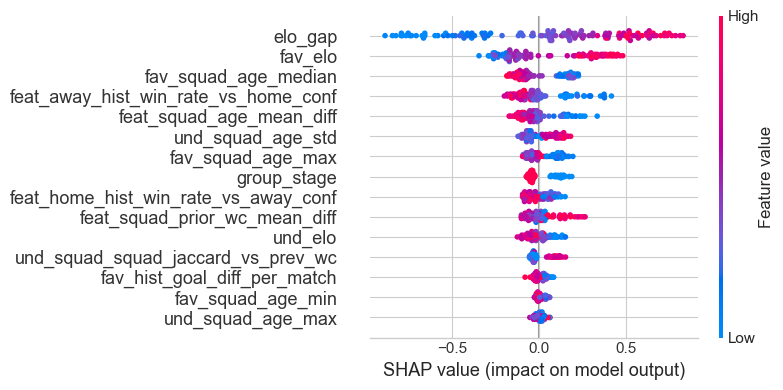

In [17]:
top_idx = [fav_num_cols.index(f) for f in top_feats.index if f in fav_num_cols]
top_names = list(top_feats.index)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    sv_cls = shap_vals[cls_idx][:, top_idx]
    sv_obj_cls = shap.Explanation(
        values=sv_cls,
        base_values=np.zeros(len(sv_cls)),
        data=X_te22[:, top_idx],
        feature_names=top_names,
    )
    print(f"Beeswarm — class {cls_idx}: {cls_name}")
    shap.summary_plot(sv_obj_cls, feature_names=top_names, show=True, plot_size=(8, 4))

## Summary

This notebook runs a **complete, self-contained pipeline** from the raw
SQLite database to multi-class predictions:

**Feature engineering (Section A)**

| Step | Key features |
|------|-------------|
| A3 Historical strength | WC win/draw/loss counts, goal diff, KO rate (past cups only, Laplace-smoothed) |
| A4 Confederation rates | Smoothed win rate vs opponent's region |
| A5 Squad | Age distribution, position mix, prior-WC experience, squad Jaccard vs last cup |
| A6 Coaches | Local coach flag, prior WCs managed, historical win rate, consecutive cups |
| A7 Schedule | Rest days since previous game in the same tournament |

**Modelling results (Section B)**

| Phase | Data | Best model | macro-AUC | macro-F1 |
|-------|------|-----------|-----------|----------|
| B3 LOTO CV | 2002–2014 (4 folds) | XGBoost | 0.671 | 0.472 |
| B4 Optuna 3-fold CV | 2002–2014 | XGBoost (tuned) | **0.711** | — |
| B5 Joint holdout | 2018 + 2022 (~128 matches) | XGBoost (tuned) | 0.627 | 0.373 |

**Data split rationale:**
2018 and 2022 are held out together as a joint test set (~128 matches, two
full tournaments). This choice is motivated by two considerations:
- **Statistical reliability:** 128 matches reduce AUC standard error to ~±0.04
  compared with ~±0.07 for a single 64-match tournament.
- **Balancing anomaly risk:** 2022 (Qatar, winter) was an unusually high-upset
  tournament; pairing it with the more typical 2018 Russia cup prevents any
  single atypical event from dominating the holdout estimate.
Training and LOTO CV are restricted to 2002–2014 (4 editions).

1. **LOTO CV (B3):** compared four classifiers using leave-one-tournament-out CV
   on the 2002–2014 window. **XGBoost** achieved the best macro-F1 (0.472) and
   macro-AUC (0.671) after fixing its class-weighting via
   `compute_sample_weight('balanced')`.
   Macro-F1 is the primary metric because the three classes
   (fav wins / draw / upset) are imbalanced (~66 / 17 / 16 %).
   `class_weight='balanced'` and `compute_sample_weight('balanced')` handle
   the imbalance without synthetic over-sampling (SMOTE), which is unreliable
   at ~256 training matches.
2. **Optuna tuning (B4):** 40-trial Bayesian search on XGBoost only
   (tuning all models inflates selection bias). Best 3-fold CV macro-AUC: **0.711**.
3. **Joint holdout (B5):** 2018 + 2022 are evaluated together (~128 matches).
   XGBoost (tuned) achieves macro-AUC 0.627, macro-F1 0.373. The confusion
   matrix shows the model predicts the majority class (fav_wins) well but
   struggles to separate draws from upsets — consistent with the inherent
   unpredictability of these rare outcomes.
4. **Note on `elo_gap`:** The Elo system is used to (a) define the
   favored/underdog direction (match label), and (b) supply `elo_gap` as a
   feature measuring how large that advantage is. These are distinct quantities
   — magnitude vs direction — so including `elo_gap` is not data leakage.
   The feature does dominate SHAP, which reflects that pre-match Elo difference
   is genuinely the strongest signal for World Cup outcomes.
5. **SHAP (B6):** `elo_gap` is the top feature, followed by historical
   win-rate and squad experience metrics.

**Caveats:** Only six tournaments (2002-2022, ~384 matches) are available.
Performance numbers should be interpreted as indicative rather than precise.
The LOTO macro-AUC is the most honest generalization estimate.
